### Computational Companion to: "Characterization of $-2$-markable  Graphs"

**Authors**: Chaochui Chen, Muhuo Liu, Haiying Shan, Zoran Stanić  
**Software**: SageMath 10.7+  
**Date**: January 2026


---

 #### This code implements calculations for the paper:"Characterization of $-2$-markable  Graphs"

# The computation in Lemma 5.2

We show that the vertex-marked graph  $\mathbf{G}=\mathbf{G}(\Sigma)$ in Case 2 is an induced subgraph of one of the following five vertex-marked graphs: $\mathbf{H}_1, \mathbf{H}_2, \cdots, \mathbf{H}_5$.

**Code Logic Summary:**

This computation searches all maximal representations of $F_4$ and classifies the resulting vertex-marked graphs.

1. **Root Generation**: Generate all long roots (±ei ± ej, i≠j) and short roots (1/2(±e1 ± e2 ± e3 ± e4)) in a 4-dimensional vector space over the rationals, representing the root system structure.

2. **Backtracking Search**: Use depth-first search (DFS) with backtracking to find all maximal representations (black_set, white_set) where:
   - black_set is a set of long roots with constraints: inner products between vectors in black_set must be in {0, 1}
   - white_set is a set of short roots with constraints: inner products between vectors in white_set must be in {0, -1}
   - Inner products between black_set and white_set vectors must be in {0, -1}
   - Vectors that are totally orthogonal to both black_set and white_set are excluded to ensure irreducibility

3. **Graph Construction**: For each maximal subset (black_set, white_set), construct a graph G with adjacency matrix defined by: a_{ij} = χ_i · χ_j - ⟨v_i, v_j⟩ for i≠j, where χ is the indicator vector for the black set black_set (marked vertices), and v_i, v_j are the corresponding root vectors.

4. **Isomorphism Classification**: Extract representatives of non-isomorphic graphs under the black-white vertex coloring, identifying the distinct vertex-marked graphs that can arise from these maximal representations.

5. **Visualization & Table**: Plot one representative per isomorphism class (black/white vertex colors) and render an HTML table listing every maximal representation with its assigned $\mathbf{H}_k$.

The five vertex-marked graphs obtained are exactly the $\mathbf{H}_1, \mathbf{H}_2, \cdots, \mathbf{H}_5$ in Case 3.



In [1]:
# Generate all long roots and short roots in a 4-dimensional vector space
# Long roots: ±ei ± ej (i ≠ j), short roots: 1/2(±e1 ± e2 ± e3 ± e4)
from itertools import product, chain, combinations
# Define 4-dimensional vector space
V = VectorSpace(QQ, 4)

# Basis vectors e1, e2, e3, e4
e = V.basis()

# Store results
long_roots = []      # ±ei ± ej (i ≠ j)
short_roots = []      # 1/2(±e1 ± e2 ± e3 ± e4)

# === 1. Generate long roots: ±ei ± ej (i < j to avoid duplicates)
for i in range(4):
    for j in range(i+1, 4):
        ei = e[i]
        ej = e[j]
        # All possible sign combinations
        long_roots.append( ei + ej)
        long_roots.append( ei - ej)
        long_roots.append(-ei + ej)
        long_roots.append(-ei - ej)

# === 2. Generate short roots: 1/2(±e1 ±e2 ±e3 ±e4)
for signs in product([1, -1], repeat=4):
    root = sum(s * e[i] for i, s in enumerate(signs))
    short_roots.append(root / 2)

# === Output results (optional: display first few)
print("Long roots (±ei ± ej, i≠j), total {}:".format(len(long_roots)))
print(long_roots[:6])  # Display first 6 examples

print("\nshort roots (1/2(±e1±e2±e3±e4)), total {}:".format(len(short_roots)))
print(short_roots[:6])  # Display first 6 examples


Long roots (±ei ± ej, i≠j), total 24:
[(1, 1, 0, 0), (1, -1, 0, 0), (-1, 1, 0, 0), (-1, -1, 0, 0), (1, 0, 1, 0), (1, 0, -1, 0)]

short roots (1/2(±e1±e2±e3±e4)), total 16:
[(1/2, 1/2, 1/2, 1/2), (1/2, 1/2, 1/2, -1/2), (1/2, 1/2, -1/2, 1/2), (1/2, 1/2, -1/2, -1/2), (1/2, -1/2, 1/2, 1/2), (1/2, -1/2, 1/2, -1/2)]


In [2]:
# Set vectors to be immutable
for v in long_roots:
    v.set_immutable()
for v in short_roots:
    v.set_immutable()

# Helper function to check if the inner product of a vector with every vector in a set is within allowed values
def is_valid_addition(new_vec, current_set, target_values):
    """
    Check if the inner product of new_vec with every vector in current_set is in target_values.
    Returns: (bool, all_zero)
    all_zero: True if new_vec is orthogonal to all vectors in current_set (and so is not irreducible).
    """
    all_zero = True
    for v in current_set:
        ip = new_vec.dot_product(v)
        if ip not in target_values:
            return False, False
        if ip != 0:
            all_zero = False
    return True, all_zero
    
# Main search function (backtracking)
maximal_representations = []

# Use a stack for DFS: each element is (black_set, white_set, remaining_long, remaining_short)
# Initialize: starting sets, all vectors are initially available
initial_black_set = [long_roots[0]] # The long root e1+e2
initial_white_set = [short_roots[-1]] # The short root -1/2(e1+e2+e3+e4)
remaining_long = long_roots[:]
remaining_short = short_roots[:]

stack = [(initial_black_set, initial_white_set, remaining_long, remaining_short)]

# To avoid duplicates, use a tuple (set_black, set_white) as a key in a set
seen = set()


    
while stack:
    black_set, white_set, rem_long, rem_short = stack.pop()

    # Try to add each remaining vector (either to black_set or white_set)
    can_add = False

    # Try adding 'long' vectors to black_set
    for v in rem_long:
        valid_black, all_zero_black = is_valid_addition(v, black_set, {0, 1})
        if not valid_black:
            continue
        valid_white, all_zero_white = is_valid_addition(v, white_set, {0, -1})
        if not valid_white:
            continue

        # Forbid adding if v is totally orthogonal to both black_set and white_set
        if all_zero_black and all_zero_white:
            continue
        

        can_add = True
        new_black_set = black_set + [v]
        new_rem = [w for w in rem_long if w != v]
        stack.append((new_black_set, white_set, new_rem, rem_short[:]))

    # Try adding 'short' vectors to white_set
    for v in rem_short:
        valid_white, all_zero_white = is_valid_addition(v, white_set, {0, -1})
        if not valid_white:
            continue
        valid_black, all_zero_black = is_valid_addition(v, black_set, {0, -1})
        if not valid_black:
            continue

        # Forbid adding if v is totally orthogonal to both black_set and white_set
        if all_zero_black and all_zero_white:
            continue

        can_add = True
        new_white_set = white_set + [v]
        new_rem = [w for w in rem_short if w != v]
        stack.append((black_set, new_white_set, rem_long[:], new_rem))

    # If no more vectors can be added, this is a maximal subset
    if not can_add:
        # Normalize black_set and white_set for deduplication: sort by string and use as tuple
        sorted_black = tuple(sorted(black_set, key=str))
        sorted_white = tuple(sorted(white_set, key=str))
        key = (sorted_black, sorted_white)
        if key not in seen:
            seen.add(key)
            maximal_representations.append((black_set[:], white_set[:]))
            num_black = len(black_set)
            num_white = len(white_set)
            print(f"Found maximal representation: |black_set|={num_black}, |white_set|={num_white}, total={num_black+num_white}")
print(f"Total number of maximal representations found: {len(maximal_representations)}")

Found maximal representation: |black_set|=6, |white_set|=4, total=10
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=6, |white_set|=4, total=10
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=5, |white_set|=2, total=7
Found maximal representation: |black_set|=5, |white_set|=2, total=7
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=6, |white_set|=4, total=10
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=5, |white_set|=2, total=7
Found maximal representation: |black_set|=5, |white_set|=3, total=8
Found maximal representation: |black_set|=5, 

In [3]:
# Convert vectors to LaTeX representation in terms of standard orthogonal basis
# Example: (1,1,0,0) -> e1+e2, (-1/2,-1/2,1/2,1/2) -> 1/2(-e1-e2+e3+e4)
from sage.misc.latex import latex
from IPython.display import Math

def vector_to_basis_latex(v):
    coeffs = list(v)
    nonzero = [(i, c) for i, c in enumerate(coeffs, start=1) if c != 0]
    if not nonzero:
        return r"\mathbf{0}"
    
    c_vals = [c for i, c in nonzero]
    
    # Check if all nonzero coefficients are ±1/2
    if all(c in [1/2, -1/2] for c in c_vals):
        g = 1/2
        inner_terms = []
        for i, c in nonzero:
            if c == 1/2:
                inner_terms.append(r"\mathbf{e}_%d" % i)
            else:  # c == -1/2
                inner_terms.append(r"-\mathbf{e}_%d" % i)
        inner = " + ".join(inner_terms).replace(" + -", " - ")
        return r"\frac{1}{2}\,(%s)" % inner

    # Otherwise, use normal representation (without extracting common factor)
    terms = []
    for i, c in nonzero:
        e = r"\mathbf{e}_%d" % i
        if c == 1:
            terms.append(e)
        elif c == -1:
            terms.append(r"-" + e)
        else:
            terms.append(latex(c) + " " + e)
    return " + ".join(terms).replace(" + -", " - ")

In [4]:
def construct_graph_from_subset(black_set, white_set):
    """
    Given black set black_set and white set white_set, construct the matrix AG and treat it as the adjacency matrix of a graph.
    Matrix AG is constructed as follows:
    - The index set is {1, ..., n}, where elements of black_set come first (total |black_set|), followed by elements of white_set (total |white_set|).
    - black_set corresponds to the marked set S (i.e., the first |black_set| indices).
    - chi corresponds to the vector chi_S defined in the paper.
    - a_{ij} = chi_i * chi_j - <vectors[i], vectors[j]>, if i != j
    - a_{ij} = 0, if i == j
    where chi[i] = 1 if i is from black_set (the first |black_set| elements), otherwise chi[i] = 0.

    Returns the graph G with adjacency matrix AG.
    """
    vectors = black_set + white_set
    n = len(vectors)
    num_black = len(black_set)  # |black_set|, the first num_black elements belong to S

    # 1. Construct indicator vector chi (n x 1 column vector)
    chi = vector(ZZ, [1 if i < num_black else 0 for i in range(n)])

    # 2. Construct adjacency matrix A(G)
    AG = matrix(ZZ, n, n)  # Use integer matrix, since results should be integer

    for i in range(n):
        for j in range(n):
            if i == j:
                AG[i, j] = 0  # Diagonal is zero
            else:
                # Compute a_{ij} as defined
                AG[i, j] = chi[i] * chi[j] - vectors[i].dot_product(vectors[j])

    # 3. Construct graph
    G = Graph(AG, format='adjacency_matrix')

    # 4. Return graph
    return G

In [5]:
"""
Group maximal_representations by isomorphism classes under black-white vertex coloring.

For each maximal_representation (black_set, white_set), we:
1. Construct the graph G from the representation
2. Compute the canonical labeled graph respecting the black-white partition
3. Use (canonical_graph6_string, num_black, num_white) as the key

Returns:
    iso_class_to_maximal_representations: Dict where
        key = (graph6_string, num_black, num_white),
              with graph6_string being the canonical encoding of the colored graph,
              and num_black, num_white the sizes of black_set and white_set respectively,
        value = list of maximal_representations [(black_set1, white_set1), (black_set2, white_set2), ...] 
                that yield the same canonical colored graph.
"""

iso_class_to_maximal_representations = {}

for maximal_representation in maximal_representations:
    black_set, white_set = maximal_representation
    num_black = len(black_set)
    num_white = len(white_set)
    black_indices = list(range(num_black))
    white_indices = list(range(num_black, num_black + num_white))
    partition = [black_indices, white_indices]

    # Construct the original graph from the black and white vector sets
    G = construct_graph_from_subset(black_set, white_set)

    # Compute the canonical labeled graph respecting the black-white vertex partition
    G_canon = G.canonical_label(partition=partition)

    # Form a composite key: (canonical graph encoding, number of black vertices, number of white vertices)
    key = (G_canon.graph6_string(), len(black_set), len(white_set))

    # Group all maximal_representations that yield the same canonical colored graph and color class sizes
    iso_class_to_maximal_representations.setdefault(key, []).append(maximal_representation)

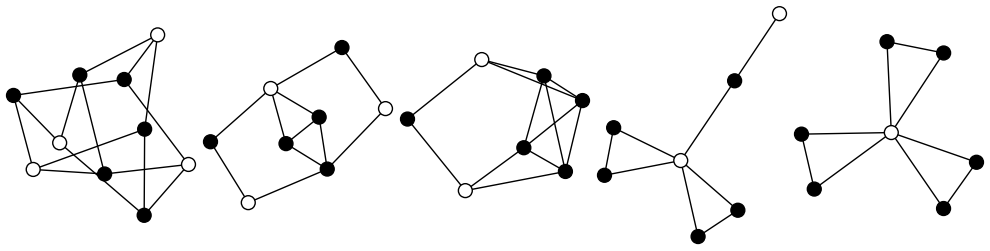

In [6]:
# Visualize the distinct vertex-marked graphs (one representative per isomorphism class)
graph_plots = [
    Graph(graph6_str).plot(vertex_colors={
        'black': list(range(num_black)),
        'white': list(range(num_black, num_black + num_white))
    }, vertex_labels=False, vertex_size=100)
    for (graph6_str, num_black, num_white), _ in iso_class_to_maximal_representations.items()
]
arr = graphics_array(graph_plots) 
arr.show(figsize=[10, 8])

In [7]:
# Generate HTML table displaying all maximal representations grouped by isomorphism class
from IPython.display import HTML

# Prepare table data
table_rows = []
row_counter = 1  # Global row number

# Iterate over all equivalence classes, in dictionary order (Python 3.7+ maintains insertion order)
for idx, (key, maximal_representations_list) in enumerate(iso_class_to_maximal_representations.items()):
    graph_name = f"\\mathbf{{H}}_{{{idx + 1}}}"  # H₁, H₂, ..., H₅
    
    # Iterate over each (black_set, white_set) in this equivalence class
    for black_set, white_set in maximal_representations_list:
        # Convert all vectors: first black_set, then white_set
        latex_parts = [vector_to_basis_latex(v) for v in black_set] + [vector_to_basis_latex(v) for v in white_set]
        vector_str = ", ".join(latex_parts)
        
        table_rows.append((row_counter, vector_str, graph_name))
        row_counter += 1

# Visualize the table
rows = "\n".join(
    f"<tr><td>{row_num}</td><td>${vec_str}$</td><td>${graph}$</td></tr>"
    for row_num, vec_str, graph in table_rows
)

table_width = "1200px" 

html = f"""
<div style="
    overflow-x: auto;
    width: 100%;
    padding: 8px 0;
">
  <table style="
      border-collapse: collapse;
      table-layout: fixed;
      width: {table_width};  
      min-width: {table_width};
  ">
    <colgroup>
      <col style="width: 60px;">
      <col style="width: calc({table_width} - 140px);"> 
      <col style="width: 80px;">
    </colgroup>
    <tr>
      <th>No.</th>
      <th>Maximal representation</th>
      <th>Vertex-marked graph</th>
    </tr>
    {rows}
  </table>

  <style>
    .output_subarea {{
        overflow-x: auto !important;
        padding-left: 0 !important;
        padding-right: 0 !important;
    }}
    .rendered_html table th,
    .rendered_html table td {{
        border: 1px solid #000;
        padding: 6px 8px;
        white-space: nowrap !important;
        text-align: left;
        background: white;
    }}
  </style>
</div>
"""

HTML(html)

No.,Maximal representation,Vertex-marked graph
1,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 - \mathbf{e}_4, \mathbf{e}_3 - \mathbf{e}_4, \mathbf{e}_2 + \mathbf{e}_3, \mathbf{e}_1 - \mathbf{e}_4, \mathbf{e}_1 + \mathbf{e}_3, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 + \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4)$",$\mathbf{H}_{1}$
2,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 - \mathbf{e}_4, \mathbf{e}_2 + \mathbf{e}_4, \mathbf{e}_2 - \mathbf{e}_3, \mathbf{e}_2 + \mathbf{e}_3, -\mathbf{e}_1 + \mathbf{e}_2, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 - \mathbf{e}_4)$",$\mathbf{H}_{1}$
3,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 + \mathbf{e}_4, -\mathbf{e}_3 + \mathbf{e}_4, \mathbf{e}_2 - \mathbf{e}_3, \mathbf{e}_1 + \mathbf{e}_4, \mathbf{e}_1 - \mathbf{e}_3, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 + \mathbf{e}_2 + \mathbf{e}_3 - \mathbf{e}_4)$",$\mathbf{H}_{1}$
4,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_1 - \mathbf{e}_4, \mathbf{e}_1 + \mathbf{e}_4, \mathbf{e}_1 - \mathbf{e}_3, \mathbf{e}_1 + \mathbf{e}_3, \mathbf{e}_1 - \mathbf{e}_2, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 + \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 + \mathbf{e}_2 + \mathbf{e}_3 - \mathbf{e}_4)$",$\mathbf{H}_{1}$
5,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 - \mathbf{e}_4, \mathbf{e}_3 - \mathbf{e}_4, \mathbf{e}_2 + \mathbf{e}_3, -\mathbf{e}_1 + \mathbf{e}_2, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4)$",$\mathbf{H}_{2}$
6,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 - \mathbf{e}_4, \mathbf{e}_2 + \mathbf{e}_4, \mathbf{e}_2 + \mathbf{e}_3, \mathbf{e}_1 + \mathbf{e}_3, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4)$",$\mathbf{H}_{2}$
7,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 - \mathbf{e}_4, \mathbf{e}_2 - \mathbf{e}_3, \mathbf{e}_2 + \mathbf{e}_3, \mathbf{e}_1 - \mathbf{e}_4, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4)$",$\mathbf{H}_{2}$
8,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 - \mathbf{e}_4, \mathbf{e}_2 + \mathbf{e}_4, \mathbf{e}_2 - \mathbf{e}_3, \mathbf{e}_1 - \mathbf{e}_3, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 - \mathbf{e}_4)$",$\mathbf{H}_{2}$
9,"$\mathbf{e}_1 + \mathbf{e}_2, \mathbf{e}_2 - \mathbf{e}_4, \mathbf{e}_1 - \mathbf{e}_4, \mathbf{e}_1 - \mathbf{e}_3, \mathbf{e}_1 + \mathbf{e}_3, \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 - \mathbf{e}_3 - \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 - \mathbf{e}_2 + \mathbf{e}_3 + \mathbf{e}_4), \frac{1}{2}\,(-\mathbf{e}_1 + \mathbf{e}_2 - \mathbf{e}_3 + \mathbf{e}_4)$",$\mathbf{H}_{2}$
10,"$\mathbf{e

# The computation in Section 6

We show that there are exactly 2182 connected graphs of order 8 satisfying $\lambda_2 \leq 1$. Among them, 1731 (approximately 79.3\%) have complements with smallest eigenvalue at least $-2$, and 2132 (approximately 97.7\%) are $-2$-markable.

In [8]:
def is_eig_2_not_exceeding_1(G):
    """
    Determines if the second largest eigenvalue of a graph G does not exceed 1.

    Mathematical explanation:
    The second largest eigenvalue of a symmetric matrix does not exceed 1 if and only if the characteristic polynomial has at most one real root in the interval (1, +∞).

    Parameters:
    G: A graph (its adjacency matrix is a real symmetric matrix)

    Returns:
    bool: True if the second largest eigenvalue ≤ 1, False otherwise
    """
    # number_of_roots_in_interval(a, b) returns the number of real roots of the characteristic polynomial in the interval [a, b]
    f = G.charpoly('x')
    return f.number_of_roots_in_interval(1, +Infinity) - (f(1) == 0) <= 1

def is_eig_min_at_least_neg_2(G):
    """
    Determines if the smallest eigenvalue of a graph (or a real symmetric matrix) G is at least -2.

    Mathematical explanation:
    The smallest eigenvalue of a real symmetric matrix is at least -2 if and only if the characteristic polynomial has no real roots in the interval (-∞, -2).

    Parameters:
    G: A graph or real symmetric matrix

    Returns:
    bool: True if the smallest eigenvalue ≥ -2, False otherwise
    """
    # number_of_roots_in_interval(a, b) returns the number of real roots of the characteristic polynomial in the interval [a, b]
    f = G.charpoly('x')
    return f.number_of_roots_in_interval(-Infinity, -2) - (f(-2) == 0) == 0

def K(G, S):
    """
    Calculate the matrix K = Chi_S*Chi_S^T - A - I,
    where Chi_S is the indicator column vector of subset S.
    """
    A = G.adjacency_matrix()
    n = A.nrows()
    # Chi_S is an n x 1 column vector. Entry is 1 if index is in S, else 0.
    Chi_S = matrix([[1] if i in S else [0] for i in range(n)])
    # K is the matrix being checked: K = Chi_S * Chi_S^T - A - I
    K = Chi_S * Chi_S.transpose() - A - identity_matrix(n)
    return K


def all_subsets(iterable):
    """
    Return all subsets (the powerset) of elements in the iterable.
    """
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

def is_negative_2_markable(G):
    """
    Check if there exists a subset S of vertices such that the smallest eigenvalue
    of the corresponding K matrix is at least -2.
    """
    n = G.num_verts()
    vertices = list(range(n))
    # Try every subset S of vertices.
    for subset in all_subsets(vertices):
        if is_eig_min_at_least_neg_2(K(G, list(subset))):
            return True    
    return False

In [9]:
# Find all connected graphs with 8 vertices such that their second largest eigenvalue is at most 1.
result_second_largest_eigenvalue_at_most_1 = []
# Among graphs in result_second_largest_eigenvalue_at_most_1, store those whose complement's minimum eigenvalue is at least -2 in result_complement,
# and those which are -2-markable (by the defined test) in result_negative_2_markable.
result_complement = []
result_negative_2_markable = []
for G in graphs.nauty_geng("8 -c"):
    if is_eig_2_not_exceeding_1(G) is True:
        result_second_largest_eigenvalue_at_most_1.append(G)
        # If the complement of G has minimum eigenvalue at least -2, add G to both result_complement and result_negative_2_markable
        if is_eig_min_at_least_neg_2(G.complement()) is True:
            result_complement.append(G)
            result_negative_2_markable.append(G)
            continue
        # Otherwise, if G is -2-markable, add it only to result_negative_2_markable
        if is_negative_2_markable(G) is True:
            result_negative_2_markable.append(G)
print("Number of connected graphs with 8 vertices whose second largest eigenvalue does not exceed 1: {}".format(len(result_second_largest_eigenvalue_at_most_1)))
print("Number of such graphs whose complement's minimum eigenvalue is at least -2: {}".format(len(result_complement)))
print("Number of such graphs that are -2-markable: {}".format(len(result_negative_2_markable)))

Number of connected graphs with 8 vertices whose second largest eigenvalue does not exceed 1: 2182
Number of such graphs whose complement's minimum eigenvalue is at least -2: 1731
Number of such graphs that are -2-markable: 2132
